# Grids of SNEC models
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [146]:
import numpy as np
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import (SNEC_output_parser, plot_vel_radius_at_time_t,
                      plot_mass_radius, plot_v_radius_time, get_times,
                      get_radius_at_time_for_m, sci_to_latex, plot_LC,
                      plot_rho_pfile, get_innerBC_t)
import astropy.units as u
import glob
from itertools import cycle
from matplotlib.colors import LinearSegmentedColormap
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [108]:
tmax = (24)*u.h

# define colormap -- to use time in hours as color value
Ncolors = 100
colors = plt.get_cmap('viridis', Ncolors)
norm = mpl.colors.Normalize(vmin=0,vmax=tmax.to(u.h).value)

sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
sm.set_array([])


In [109]:
def get_energy_from_folder(folder):
    return float(folder.split("_e_")[-1].rstrip("/").replace("d", "e"))

In [216]:
root3 = "/home/mrenzo/Runs/SNEC_grid/long_runs3/15Msun/" # 15Msun_progenitor/ # s30VdJNL_0.33/"
models3 = sorted(glob.glob(root3+"*.*/"), key=get_energy_from_folder)
root2 = "/home/mrenzo/Runs/SNEC_grid/long_runs2/15Msun/" # 15Msun_progenitor/ # s40VdJNL_0.44/"
models2 = sorted(glob.glob(root2+"*.*/"), key=get_energy_from_folder)
root1 = "/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/" # 15Msun_progenitor/ # s40VdJNL_0.44/"
models1 = sorted(glob.glob(root1+"*.*/"), key=get_energy_from_folder)
models = models1+models2+models3
print(models)
print(len(models))
BE = 0.64589366106874414e51 *u.erg # see Table 2 in Morozova et al. 2015

['/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/long_runs/15Msun/bomb_final_e_1.0d51/', '/home/mrenzo/Runs/SNEC_grid/long_runs2/15Msun/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/long_runs2/15Msun/bomb_final_e_1.0d51/', '/home/mrenzo/Runs/SNEC_grid/long_runs3/15Msun/bomb_final_e_0.0d0/', '/home/mrenzo/Runs/SNEC_grid/long_runs3/15Msun/bomb_final_e_1.0d48/', '/home/mrenzo/Runs/SNEC_grid/long_runs3/15Msun/bomb_final_e_1.0d51/']
7


In [217]:
def get_shock_pos(data_folder):
    shockpos = data_folder+'/Data/velshock_index.dat'
    shock_data = np.genfromtxt(shockpos)
    i_shock = shock_data[:, 0]
    t_shock = shock_data[:,1]*u.s
    r_shock = shock_data[:,2]*u.cm
    return i_shock, t_shock, r_shock

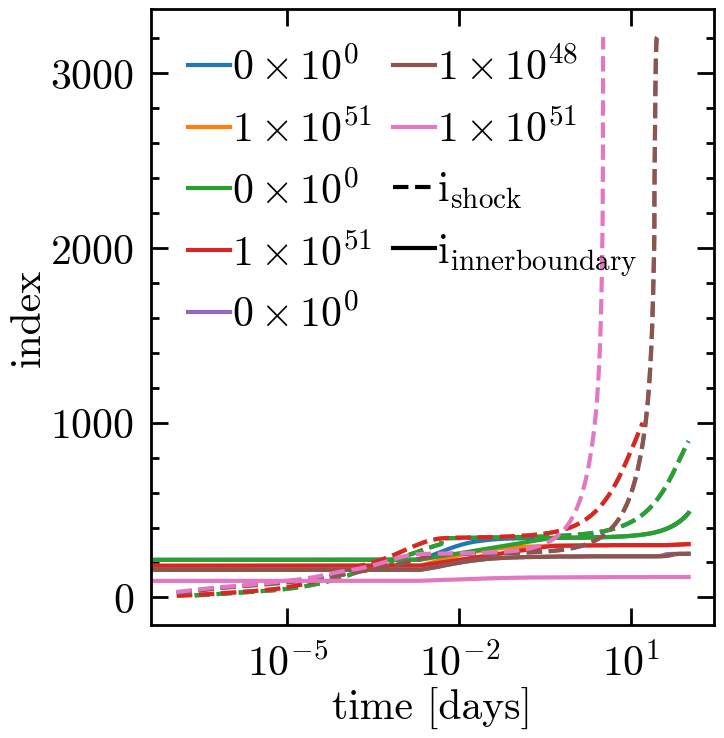

In [218]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])

for i, m in enumerate(models):
    t, iBC = get_innerBC_t(m+'Data/inner_boundary.dat')
    ax.plot(t.to(u.d), iBC, label=f"{sci_to_latex(get_energy_from_folder(m))}", c=f"C{i}")
    # ax.scatter(t.to(u.d), iBC, label=f"{sci_to_latex(get_energy_from_folder(m))}", c=f"C{i}", marker='x')
    if True: # try:
        i_s, t_s, r_s = get_shock_pos(m)
        ax.plot(t_s.to(u.d), i_s,  c=f"C{i}", ls='--')
        # ax.scatter(t_s.to(u.d), i_s, c=f"C{i}", marker='o')
    # except:
        
ax.plot(np.nan, np.nan,c='k' , ls='--', label=r"$i_{\rm shock}$")
ax.plot(np.nan, np.nan,c='k' ,  label=r"$i_{\rm inner boundary}$")
ax.set_xlabel(r"time [days]")
ax.set_xscale('log')
ax.set_ylabel(r"index")
ax.legend(ncols=2, handlelength=1., columnspacing=0.5, handletextpad=0.05)

In [219]:
# progenitor CO core mass
mco_progenitor = 3.27*u.Msun
mhe_progenitor = 5.1*u.Msun

(-4.0, 25.0)

/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  func(*args, **kwargs)
/home/mrenzo/Documents/Research/codes/miniforge3/envs/dev_SNEC/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.canvas.print_figure(bytes_io, **kw)


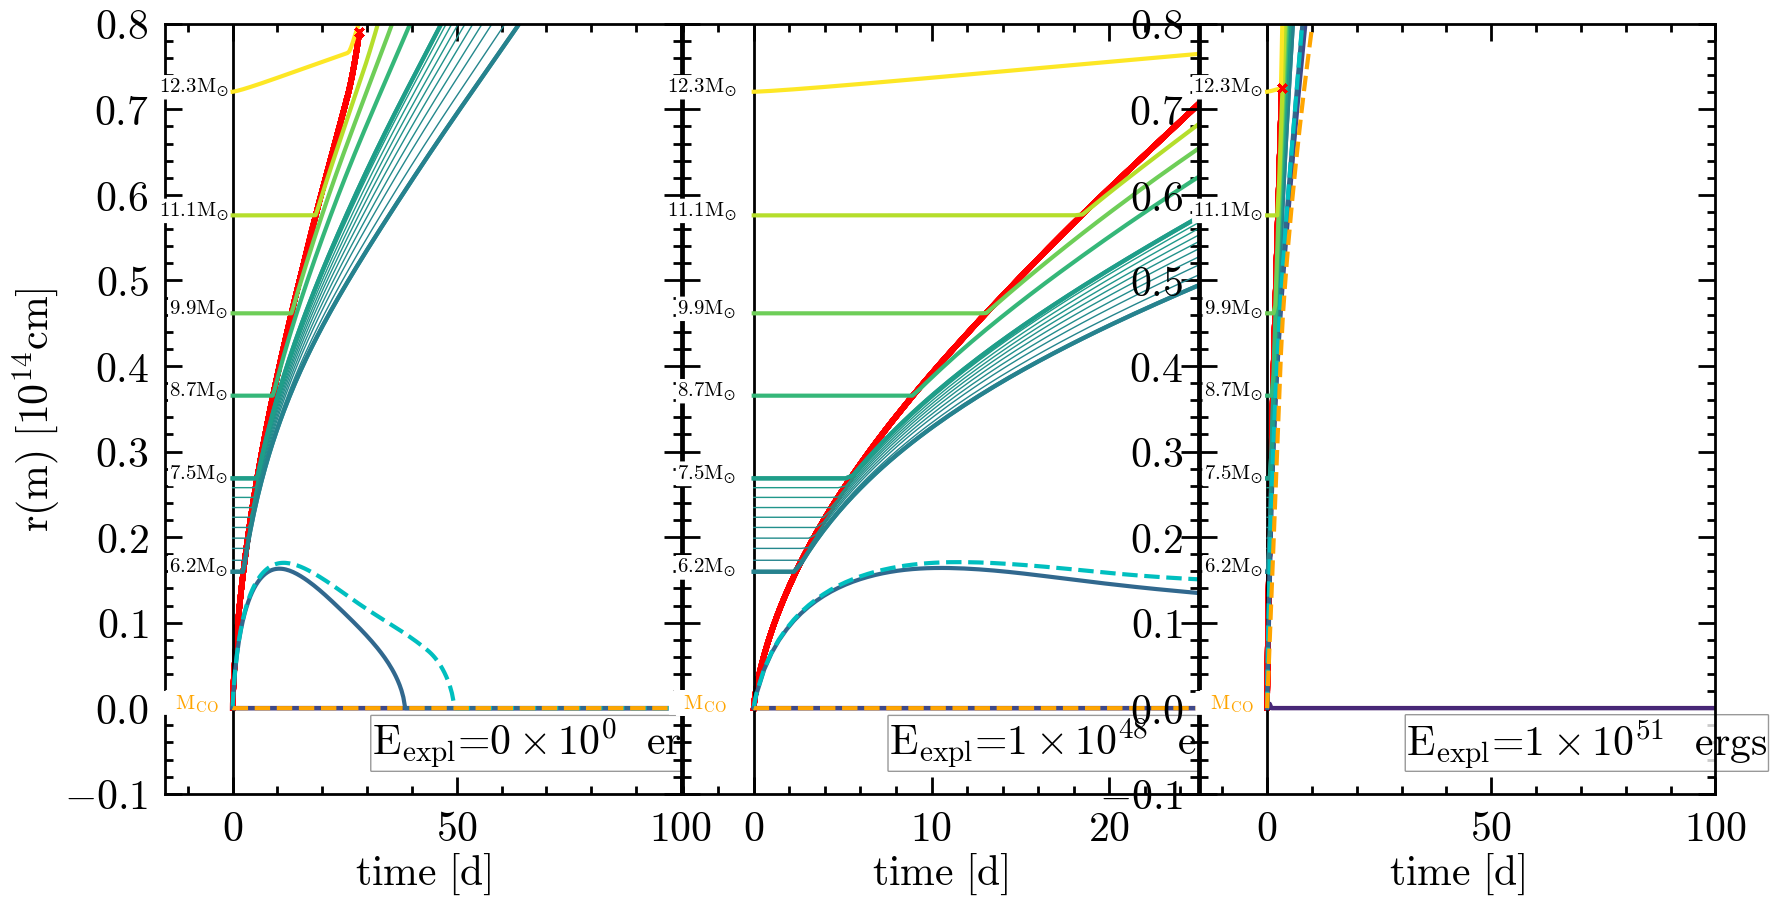

In [221]:
# follow one specific mass coordinate in time
fig = plt.figure(figsize=(20,10))
gs = gridspec.GridSpec(100, 150)
ax1 = fig.add_subplot(gs[:, :50])
ax2 = fig.add_subplot(gs[:, 50:100])
ax3 = fig.add_subplot(gs[:, 100:])
axes = [ax1, ax2, ax3]


masses = np.linspace(1.4, 12.3, 10)
ii = 4
minimasses = np.linspace(masses[ii], masses[ii+1], 10)
allmasses = sorted(np.concatenate((masses, minimasses)))
colors = plt.cm.viridis(np.linspace(0,1,len(masses)))
cmap = LinearSegmentedColormap.from_list("custom", [colors[ii], colors[ii+1]])
colorsmini = cmap(np.linspace(0,1,len(minimasses)))


for k, mod in enumerate(models3):
    ax = axes[k]
    for i, m in enumerate(allmasses): 
        t, r = get_radius_at_time_for_m(mod+'Data/mass.xg', mcoord=m*u.Msun)
        # purge negatives
        kk = (r<0)
        r[kk] = 0.0*u.cm
        x, y = t.to(u.d).value, r.to(10**14 * u.cm).value
        if ((m in minimasses) and (m not in masses)):
            lw = 1
            color = colorsmini[np.argmin(np.absolute(minimasses-m))]
        else:
            ax.text(x[0]-1, y[0], f"{m:.1f}"+r"$M_{\odot}$", size=15,
                    ha="right" , bbox=dict(boxstyle="round,pad=0.02",
                                          facecolor="white", edgecolor="white", alpha=1.0))
            color=colors[np.argmin(np.absolute(masses-m))]
            lw=3
        ax.plot(x, y, c=color, lw=lw)
        try:
            i_shock, t_shock, r_shock = get_shock_pos(mod)
            ax.plot(t_shock.to(u.d), r_shock.to(10**14 * u.cm), c='r', lw=4, zorder=0)
            ax.plot(t_shock.to(u.d)[-1], r_shock.to(10**14 * u.cm)[-1], c='r', zorder=10, marker='x')
        except:
            print(mod, "no shock?")

    # add He core mass
    t, r = get_radius_at_time_for_m(mod+'Data/mass.xg', mcoord=mhe_progenitor)
    # purge negatives
    kk = (r<0)
    r[kk] = 0.0*u.cm
    x, y = t.to(u.d).value, r.to(10**14 * u.cm).value
    ax.plot(x, y, c='c', lw=3, ls='--')
    ax.text(x[0]-1, y[0], r"  $M_{\rm He}$  ", size=15, color='c',
            ha="right" , bbox=dict(boxstyle="round,pad=0.02",
                                   facecolor="white", edgecolor="w", alpha=1.))            
    # add CO core mass
    t, r = get_radius_at_time_for_m(mod+'Data/mass.xg', mcoord=mco_progenitor)
    # purge negatives
    kk = (r<0)
    r[kk] = 0.0*u.cm
    x, y = t.to(u.d).value, r.to(10**14 * u.cm).value
    ax.plot(x, y, c='orange', lw=3, ls='--')
    ax.text(x[0]-1, y[0], r"  $M_{\rm CO}$  ", size=15, color='orange',
            ha="right" , bbox=dict(boxstyle="round,pad=0.02",
                                   facecolor="white", edgecolor="white", alpha=1))

            
    # ax.set_yscale('log')
    ax.set_xlabel(r"$time\ [d]$")
    ax.axvline(0, 0, 1, c='k', ls='-', lw=2, zorder=0)

    ax.set_xlim(-15,100)  # 1e14cm scale
    ax.set_ylim(-0.1, 0.8)  # 1e14cm scale
    # ax.set_xscale('log')
    ax.text(0.4, 0.05, r"$E_{\rm expl}$="+f"{sci_to_latex(get_energy_from_folder(mod))}  ergs",
            size=30, transform=ax.transAxes,
            bbox=dict(boxstyle="round,pad=0.02", facecolor="white", edgecolor="#808080", alpha=0.8),
            zorder=k)
    # ax.axvspan()


ax1.set_ylabel(r"$r(m) \ [10^{14}\mathrm{cm}]$")
ax2.set_yticklabels([])
ax2.set_xlim(-4, 25)  # 1e14cm scale



/home/mrenzo/Runs/SNEC_grid/long_runs3/15Msun/bomb_final_e_0.0d0/


12.292135711144635 solMass


12.292135711144635 solMass


12.292135711144635 solMass


12.292135711144635 solMass


...

12.292135711144635 solMass


12.292135711144635 solMass


12.292135711144635 solMass


12.292135711144635 solMass


/tmp/ipykernel_1405454/2494096559.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(minr.to(u.cm).value, 5.0e14)


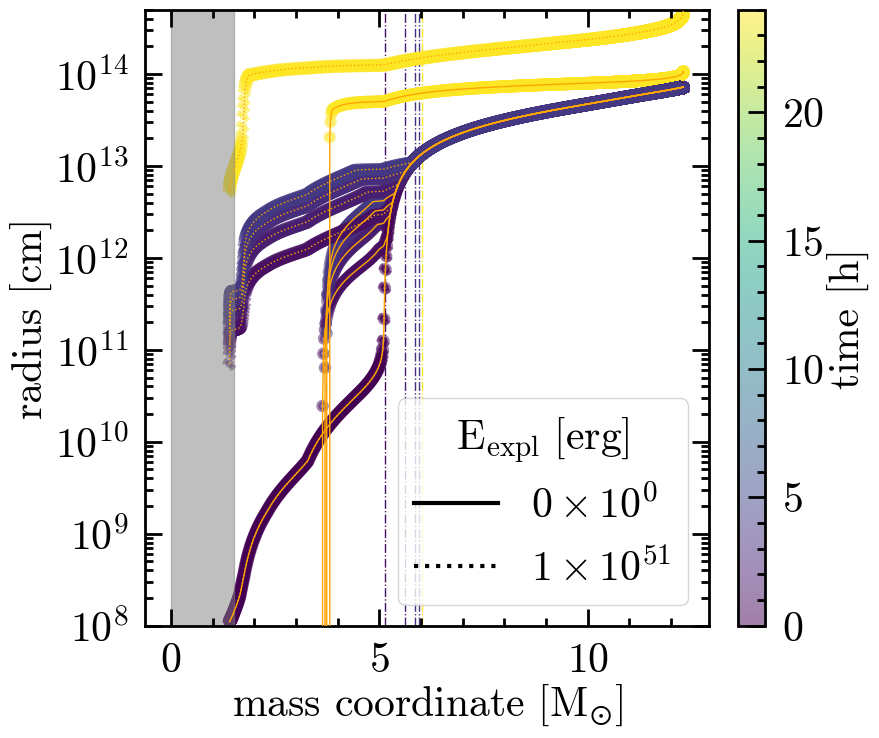

In [85]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

bomb_spread = 0.1 *u.Msun #  see parameters file
linestyles = ["-", ":"]
minr=1e99*u.cm

for j, m in enumerate(models):
    print(m)
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        try:
            tiBC, iBC = get_innerBC_t(m+'/Data/inner_boundary.dat')
        except FileNotFoundError:
            tiBc, iBC = np.nan, np.nan
        for i, t in enumerate(times[::20]):
            m, r, p, c = plot_mass_radius(t, outfile, ax=ax, scatter=True,
                                          i_min=iBC[i],
                                          alpha=0.5, # s=10*(1+i),
                                          # color=colors[j],
                                          ls = linestyles[j],
                                          # label = f"{t.to(u.h).value:.1f}",
                                          lw=3+j,
                                          vmin = 0,
                                          vmax = tmax.to(u.h).value
                                          )
            print(max(m).to(u.Msun))
            # print(linestyles[j])
            if t >= tmax: break
            if min(r)<minr: minr = min(r)
    except:
        print("FAILED")
        pass
plt.colorbar(p, cax=cax, norm=norm)

# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")
ax.axvspan(xmin=0, xmax=(1.4*u.Msun+bomb_spread.to(u.Msun)).value, alpha=0.5, color="#808080")
# ax.set_xlim(0, 7.0)
ax.set_yscale('log')
# ax.set_yscale('symlog',linthresh=1.5e11, linscale=0.66)
ax.set_ylim(1e8, 1e13)
ax.set_ylim(minr.to(u.cm).value, 5.0e14)   

cax.set_ylabel(r"time [h]")
ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$")
ax.plot(np.nan, np.nan, c='k', ls='-', label=f"{sci_to_latex(get_energy_from_folder(models[0]))}")
ax.plot(np.nan, np.nan, c='k', ls=':', label=f"{sci_to_latex(get_energy_from_folder(models[-1]))}")
ax.legend(title=r"$E_{\rm expl} \ [\mathrm{erg}]$", frameon=True)



/home/mrenzo/Runs/SNEC_grid/long_runs3/15Msun/bomb_final_e_0.0d0/


/home/mrenzo/Runs/SNEC_grid/long_runs3/15Msun/bomb_final_e_1.0d51/


Text(0.5, 0, 'Mass coordinate [$M_{\\odot}$]')

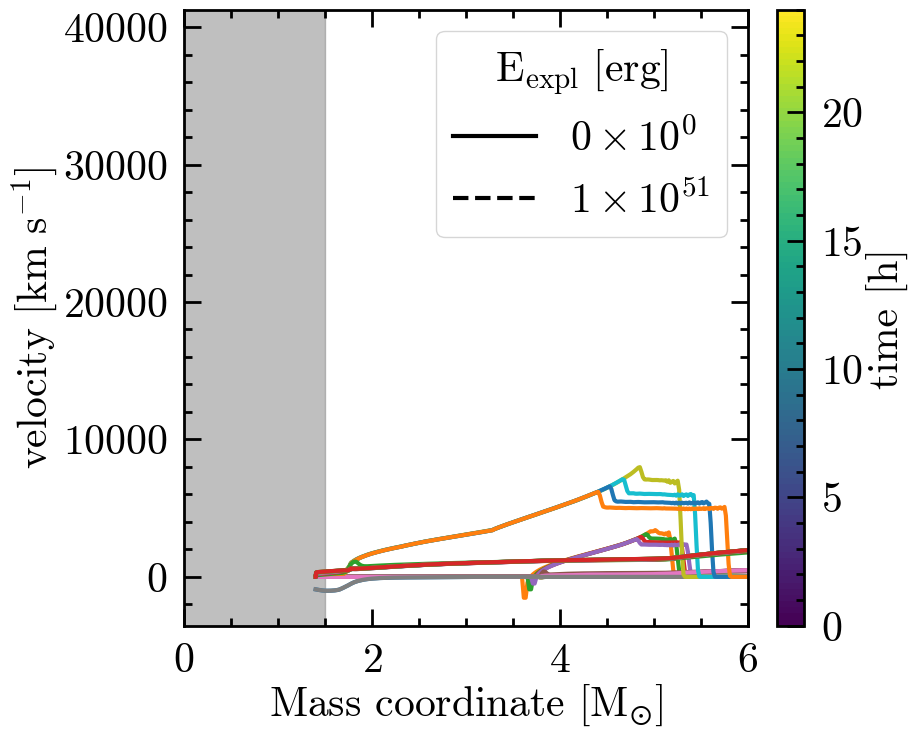

In [ ]:
fig = plt.figure()
gs = gridspec.GridSpec(100, 110)
ax = fig.add_subplot(gs[:, :100])
cax = fig.add_subplot(gs[:, 105:])

ls = linestyles = [
    (0, (1, 10)),
    (0, (1, 5)),
    (0, (1, 1)),
    
    (5, (10, 3)),
    (0, (5, 10)),] # to distinguish models

plt.colorbar(sm, cax=cax, # ticks=np.linspace(0,2,N), 
             # boundaries=np.arange(-0.05,2.1,.1)
             )
cax.set_ylabel(r"time [h]")

skip=20
for j, m in enumerate(models3): # [models[0], models[-1]]):
    print(m)
    times = get_times(m+'Data/mass.xg')
    tiBC, iBC = get_innerBC_t(m+'/Data/inner_boundary.dat')
    for i, t in enumerate(times[::skip]):
        k = np.argmin(np.absolute(times[::skip]-t))
        mm, v, p = plot_vel_radius_at_time_t(t, m+'/Data/vel.xg', ax=ax,
                                             # vmin = min(times[:10].to(u.h).value),
                                             # vmax = max(times[:10].to(u.h).value),
                                             # c=colors(norm(t.to(u.h).value)),
                                             # ls=linestyles[j],
                                             scatter=False
                                             )
        # print(np.shape(mm))
        # ax.axvline(mm[j, iBC].to(u.Msun).value, 0,1,c=colors(norm(t.to(u.h).value)))

        
ax.plot(np.nan, np.nan, c='k', ls='-', label=f"{sci_to_latex(get_energy_from_folder(models[0]))}")
ax.plot(np.nan, np.nan, c='k', ls='--', label=f"{sci_to_latex(get_energy_from_folder(models[-1]))}")

cax.set_ylabel(r"time [h]")
ax.set_xlim(0,6)
ax.axvspan(xmin=0, xmax=1.4+bomb_spread.to(u.Msun).value, alpha=0.5, color="#808080")
ax.legend(title=r"$E_{\rm expl} \ [\mathrm{erg}]$", frameon=True)
# ax.set_ylim(-1000, 1000)
ax.set_ylabel(r"velocity [$\mathrm{km\ s^{-1}}$]")
ax.set_xlabel(r"Mass coordinate [$M_{\odot}$]")

AttributeError: 'str' object has no attribute 'to'

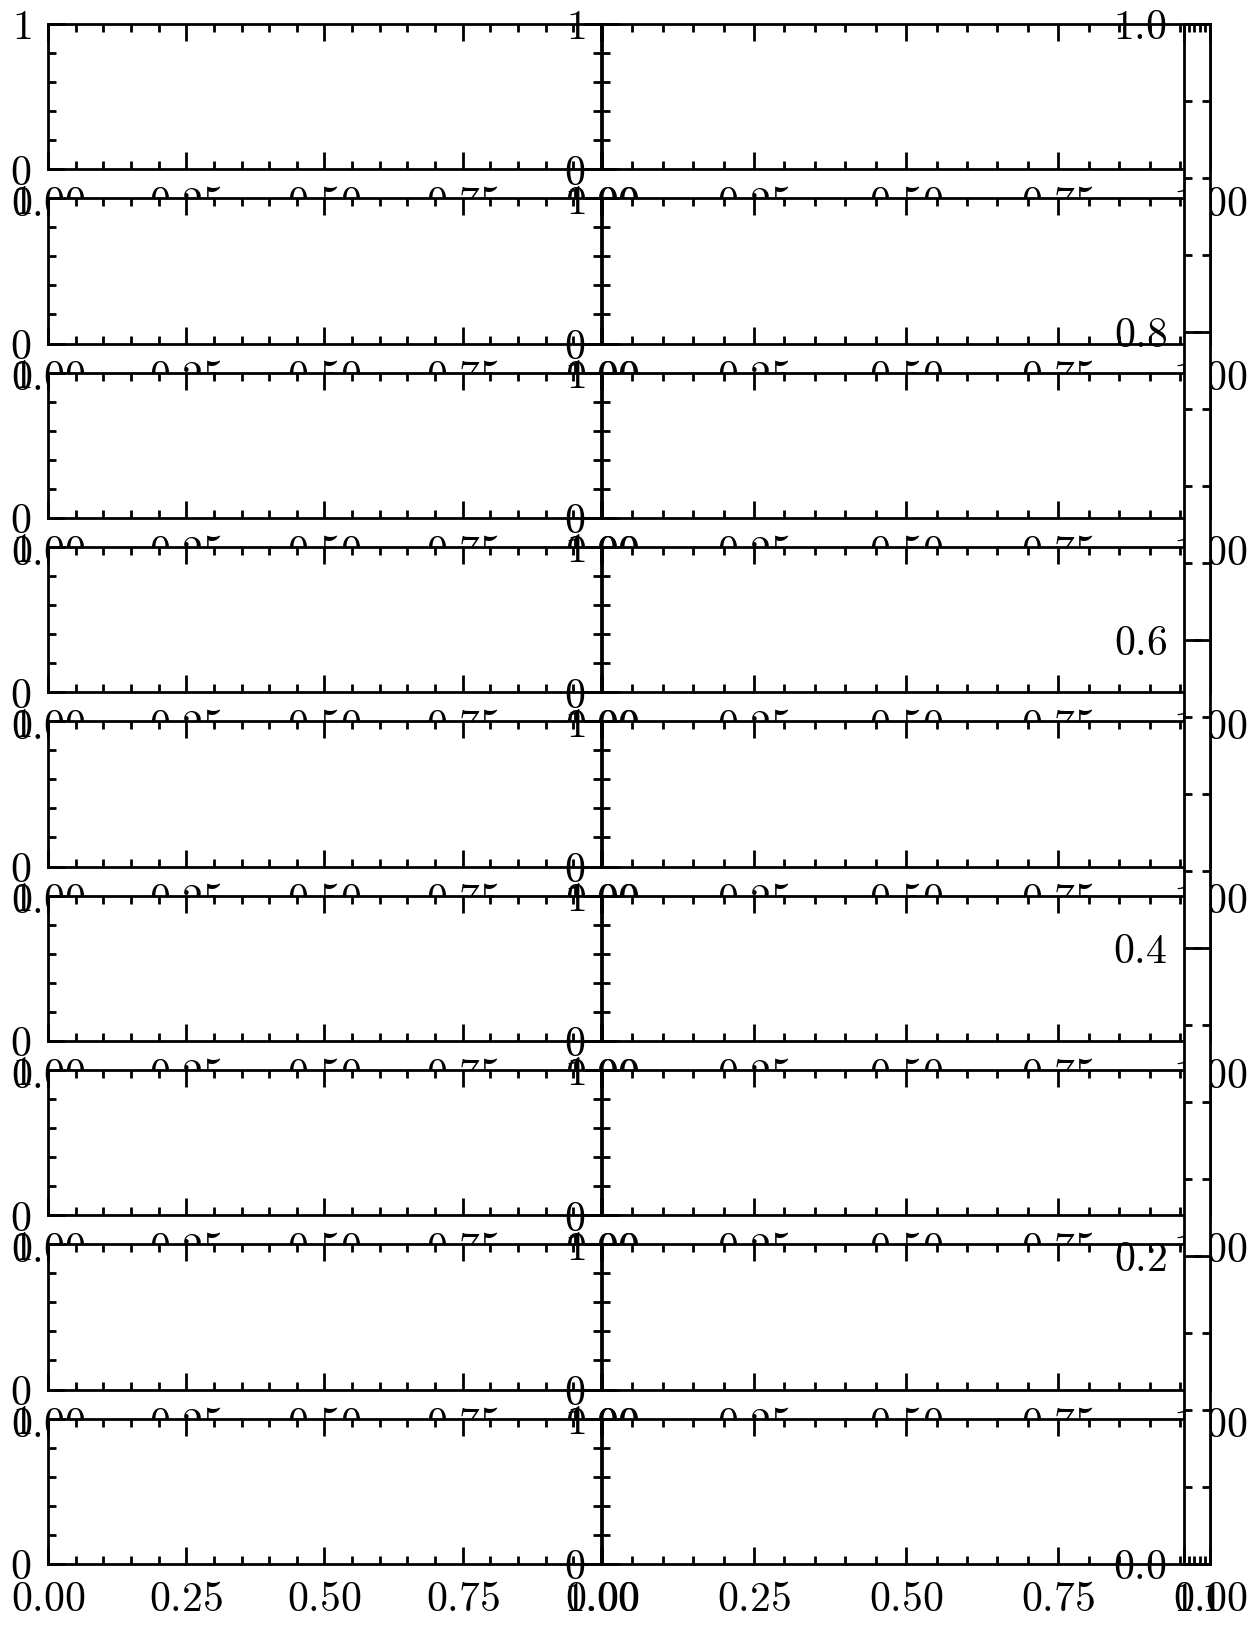

AttributeError: 'str' object has no attribute 'to'

In [35]:
fig = plt.figure(figsize=(15,20))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*.*/"), key=get_energy_from_folder)
# print(len(models15), models15)
for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times):
            # print(t.to(u.h))
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            xmin = min(m.to(u.Msun))               
    except:
        print("FAILED")
        pass

s30 = "/home/mrenzo/Runs/SNEC_grid/s30VdJNL_0.33/"
models30 = sorted(glob.glob(s30+"*.*/"), key=get_energy_from_folder)
# print(len(models30), models30)
for j, m in enumerate(models30):
    ax = axes[2*j+1]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        outfile = m+'Data/mass.xg'
        times = get_times(outfile)
        for i, t in enumerate(times):
            if t.to(u.h) >= tmax: break
            m, r, p = plot_mass_radius(t, outfile, ax=ax, alpha=0.5, # s=10*(1+i),
                                       # c=colors[j],
                                       # ls = linestyles[j],
                                       label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=tmax.value)
            
    except:
        print("FAILED")
        pass
xmin = min(m.to(u.Msun))
plt.colorbar(p, cax=cax)
# ax.legend(frameon=True, ncol=2, columnspacing=0.5, handlelength=0.05, title="time [h]")

for i, ax in enumerate(axes):
    # ax.set_xlim(0, 5.0)
    ax.set_yscale('log')
    if (i%2 !=0): ax.set_yticklabels([])
    if (i != 16) and (i !=17): ax.set_xticklabels([])
    
axes[0].set_title(r"$15M_{\odot}$ RSG", size=30)
axes[1].set_title(r"$30M_{\odot}$ WR", size=30)
axes[16].set_xlabel(r"mass coordinate [$M_{\odot}$]")
axes[17].set_xlabel(r"mass coordinate [$M_{\odot}$]")
cax.set_ylabel(r"time [h]")
# ax.set_xlabel(r"mass coordinate [$M_{\odot}$]")
# ax.set_ylabel(r"radius [cm]") #(r"$\log_{10}(r/\mathrm{cm})$") 

In [ ]:
fig = plt.figure(figsize=(20,30))
gs = gridspec.GridSpec(9, 210)  # 16 rows, 2 cols of plots + colorbar
axes = []
for row in range(9):
    ax_left = fig.add_subplot(gs[row, :100])
    ax_right = fig.add_subplot(gs[row, 100:210])
    axes.append(ax_left)
    axes.append(ax_right)

cax = fig.add_subplot(gs[:, 205:])

bomb_spread = 0.1 *u.Msun #  see parameters file

# for i, ax in enumerate(axes):
#     ax.text(0.5, 0.5, i)

s15 = "/home/mrenzo/Runs/SNEC_grid/15Msun_progenitor/" # 30Msun_VdJNL/"
models15 = sorted(glob.glob(s15+"*/*.*/"), key=get_energy_from_folder)

for j, m in enumerate(models15):
    ax = axes[2*j]
    ax.axvspan(xmin=xmin.value, xmax=bomb_spread.value, alpha=0.5, color="#808080")
    try:
        vel_file = m+'Data/vel.xg'
        mass_file = m+'Data/mass.xg'
        times = get_times(vel_file)
        # times = [times[0], times[int(len(times)/2.)], times[-1]]
        for i, t in enumerate(times[::10]):           
            m, r, p = plot_v_radius_time(t, vel_file, mass_file,
                                         ax=ax, alpha=0.5, # s=10*(1+i),
                                         # c=colors[j],
                                         # ls = linestyles[j],
                                         label=f"{t.to(u.h).value:.1f}", vmin=0, vmax=240)
            xmin = min(m.to(u.Msun))
    except:
        print("FAILED")
        pass


0.0 erg / s 9.3532836059e+41 erg / s
0.0 erg / s 9.3532836059e+41 erg / s
0.0 erg / s 9.3532836059e+41 erg / s


/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:440: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{[erg\\ s^{-1}]})$')

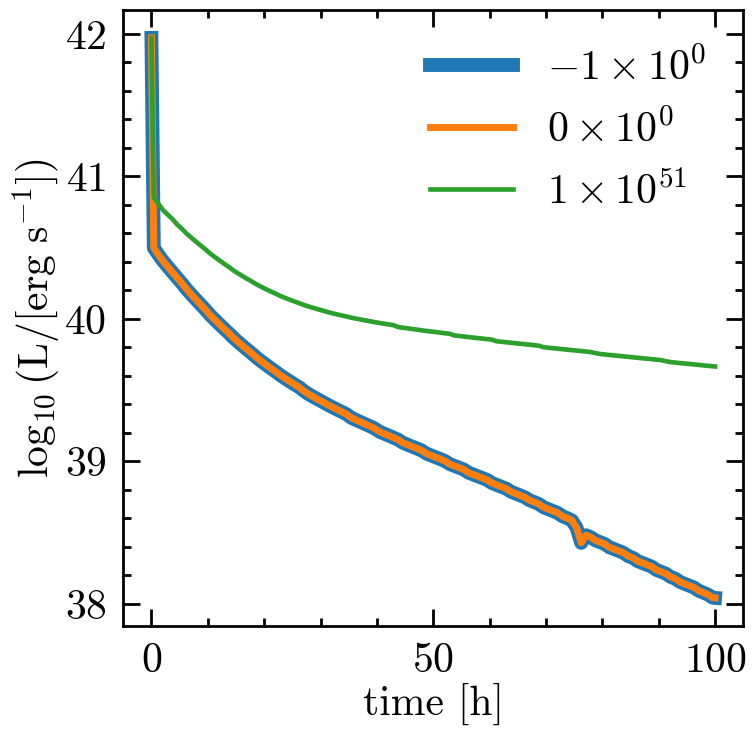

In [11]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, m in enumerate(models):
    # try:
    fname = m+'/Data/lum_observed.dat'
    L, t = plot_LC(fname, ax=ax, label=sci_to_latex(get_energy_from_folder(m)), lw=10/(i+1))
    print(min(L), max(L))
    # except: # IndexError:
    #     pass
    #    print(m, "failed")
    
ax.legend()
ax.set_xlabel(r"time [h]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{[erg\ s^{-1}]})$")

0.0 s 8640000.0 s


0.0 s 8640000.0 s


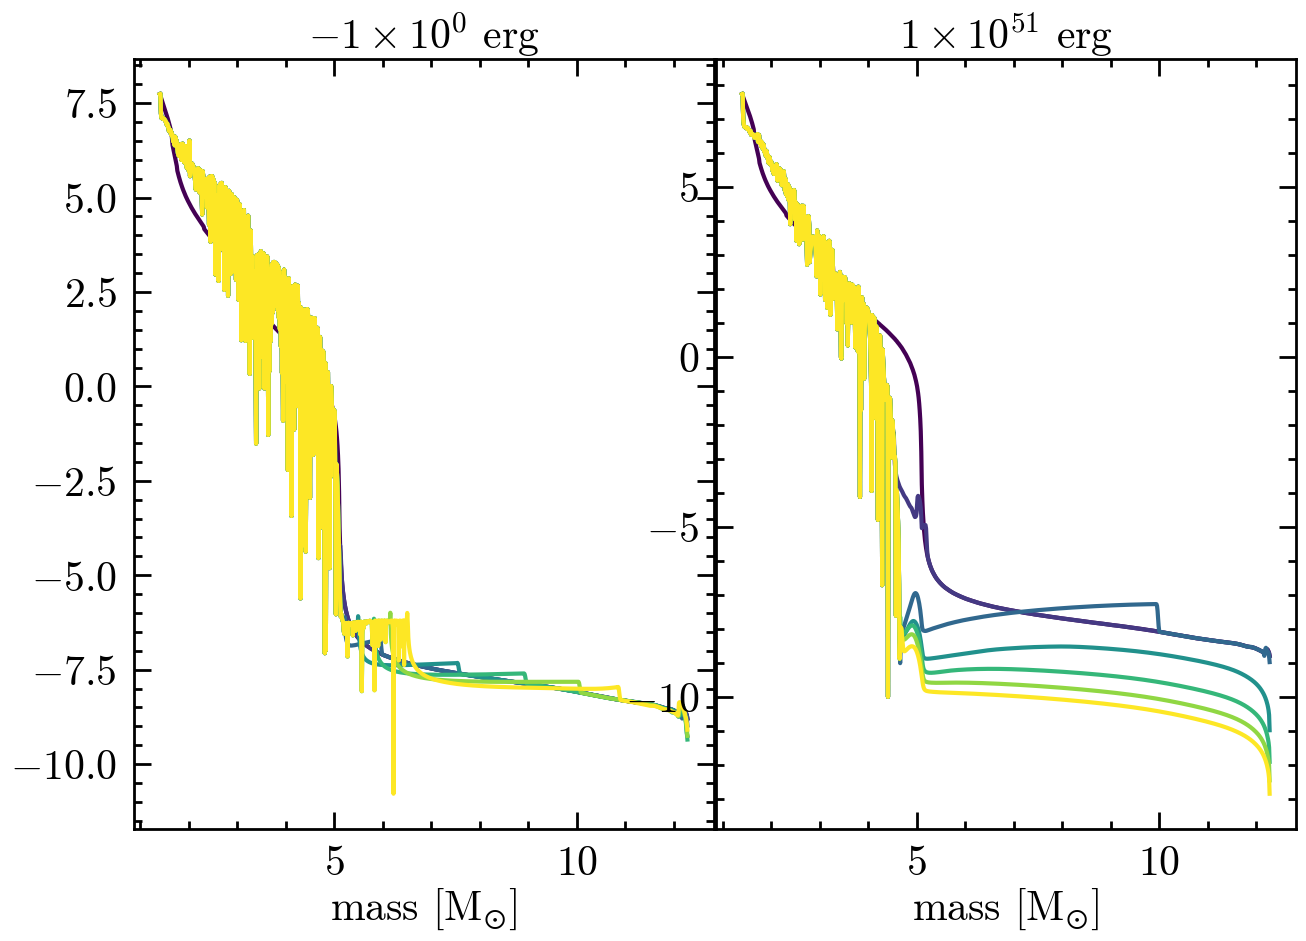

In [20]:
# density profiles
fig = plt.figure(figsize=(15,10))
gs = gridspec.GridSpec(100, 100)
ax1 = fig.add_subplot(gs[:, :50])
ax2 = fig.add_subplot(gs[:, 50:])
axes = [ax1, ax2]
skip = 50

for j, m in enumerate([models[0], models[-1]]):
    ax = axes[j]
    ax.set_title(f"{sci_to_latex(get_energy_from_folder(m))} erg", size=30)
    ax.set_xlabel(r"mass [$M_{\odot}$]")
    try:
        outfile = m+'Data/rho.xg'
        times = get_times(outfile)
        colors = plt.cm.viridis(np.linspace(0,1, len(times[::skip])))
        for i, t in enumerate(times[::skip]):
            plot_rho_pfile(t, outfile, ax=ax, color=colors[i])
    except:
        print(m)
        